Kütüphanelerin ve Veri Setinin Yüklenmesi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

DATASET_PATH = "../data/raw/company_esg_financial_dataset.csv"

# Uyarıları daha temiz bir görüntü için filtreleyelim
warnings.filterwarnings('ignore')

# Görselleştirme ayarları
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# Veri setini okuma
try:
    df = pd.read_csv(DATASET_PATH)
    print("Veri seti başarıyla yüklendi.")
    print(f"Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
except FileNotFoundError:
    print("Hata: Dosya bulunamadı. Lütfen dosya yolunu kontrol edin.")

# İlk 5 satıra hızlı bir bakış
df.head()

Veri seti başarıyla yüklendi.
Veri seti boyutu: 11000 satır, 16 sütun


,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
0,1,Company_1,Retail,Latin America,2015,459.2,6.0,337.5,NaN,57.0,60.7,33.5,76.8,35577.4,17788.7,71154.7
1,1,Company_1,Retail,Latin America,2016,473.8,4.6,366.6,3.2,56.7,58.9,32.8,78.5,37314.7,18657.4,74629.4
2,1,Company_1,Retail,Latin America,2017,564.9,5.2,313.4,19.2,56.5,57.6,34.0,77.8,45006.4,22503.2,90012.9
3,1,Company_1,Retail,Latin America,2018,558.4,4.3,283.0,-1.1,58.0,62.3,33.4,78.3,42650.1,21325.1,85300.2
4,1,Company_1,Retail,Latin America,2019,554.5,4.9,538.1,-0.7,56.6,63.7,30.0,76.1,41799.4,20899.7,83598.8


Genel Veri Yapısı ve Türlerinin İncelenmesi

In [2]:
print("--- Veri Seti Genel Bilgileri ---")
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nDescribe:")
df.describe(include="all")


--- Veri Seti Genel Bilgileri ---
Shape: (11000, 16)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         10000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyCons

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
count,11000.000000,11000,11000,11000,11000.000000,11000.000000,11000.000000,11000.000000,10000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,1.100000e+04,1.100000e+04
unique,NaN,1000,9,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Company_1000,Healthcare,Asia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,11,1331,1672,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,500.500000,NaN,NaN,NaN,2020.000000,4670.850591,10.900455,13380.622236,4.830370,54.615273,56.416991,55.660582,51.767655,1.271462e+06,5.600442e+05,1.165839e+07
std,288.688113,NaN,NaN,NaN,3.162421,9969.954369,8.758711,39922.870373,9.424787,15.893937,26.767233,23.356152,25.323370,5.067760e+06,1.565686e+06,5.095836e+07
min,1.000000,NaN,NaN,NaN,2015.000000,35.900000,-20.000000,1.800000,-36.000000,6.300000,0.000000,0.000000,0.000000,2.042200e+03,1.021100e+03,5.105500e+03
25%,250.750000,NaN,NaN,NaN,2017.000000,938.775000,5.300000,1098.525000,-1.325000,44.100000,34.700000,37.600000,30.775000,1.228530e+05,6.488467e+04,3.069161e+05
50%,500.500000,NaN,NaN,NaN,2020.000000,1902.300000,10.500000,3096.450000,4.900000,54.600000,55.600000,55.150000,52.100000,2.920734e+05,2.038805e+05,1.221745e+06
75%,750.250000,NaN,NaN,NaN,2023.000000,4342.625000,16.300000,9995.500000,11.000000,65.600000,79.000000,73.800000,73.000000,7.407311e+05,5.251880e+05,5.616437e+06


uniq

In [21]:

print(df.Industry.unique())
print(df.Region.unique())

['Retail' 'Transportation' 'Technology' 'Finance' 'Healthcare' 'Energy'
 'Consumer Goods' 'Utilities' 'Manufacturing']
['Latin America' 'Asia' 'Africa' 'Middle East' 'Oceania' 'Europe'
 'North America']


Eksik Veri Analizi


--- Eksik Değerler ---


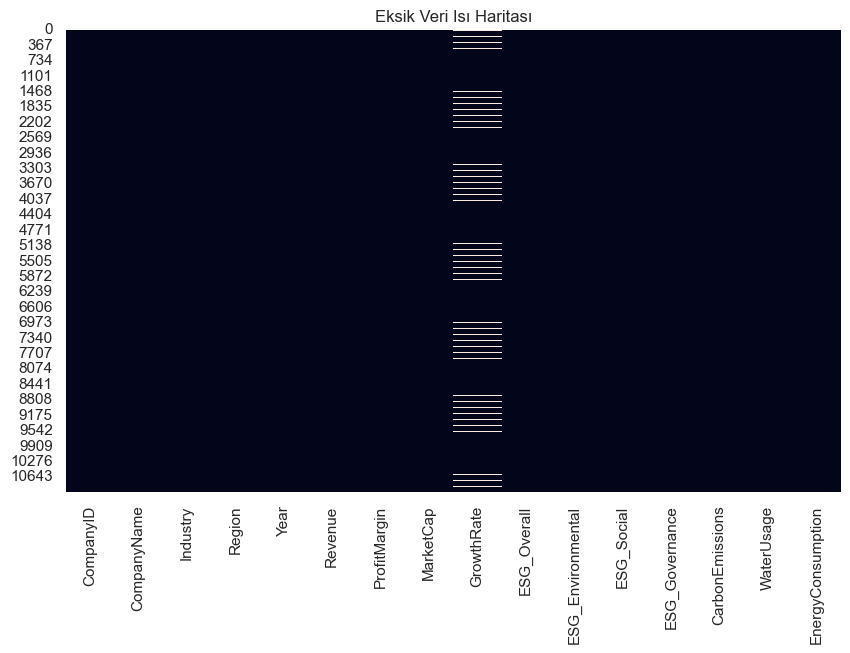

In [22]:
print("\n--- Eksik Değerler ---")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "MissingCount": missing,
    "MissingPercent": missing_pct
})

missing_df

# Eksik değerlerin sayısı ve yüzdesi
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Eksik Veri Isı Haritası")
plt.show()


=== SEKTÖR BAZINDA MEDYAN DEĞERLER ===
                Revenue  ProfitMargin  MarketCap  GrowthRate  ESG_Overall  \
Industry                                                                    
Technology      7413.50         19.30    33455.0         9.2        63.50   
Healthcare      2930.60         15.50     7677.0         7.1        58.20   
Consumer Goods  1526.20         10.80     2777.7         5.3        55.85   
Finance         3748.50         14.10     6694.7         5.1        64.00   
Transportation   814.40          4.60     1057.0         4.5        47.00   
Retail          1093.55          5.35     1168.6         4.3        56.10   
Manufacturing   1453.20          8.50     1786.8         3.9        49.70   
Energy          5601.25         10.70     9448.5         2.1        48.85   
Utilities       1046.70          9.70     1097.9         2.0        51.80   

                ESG_Environmental  ESG_Social  ESG_Governance  \
Industry                                        

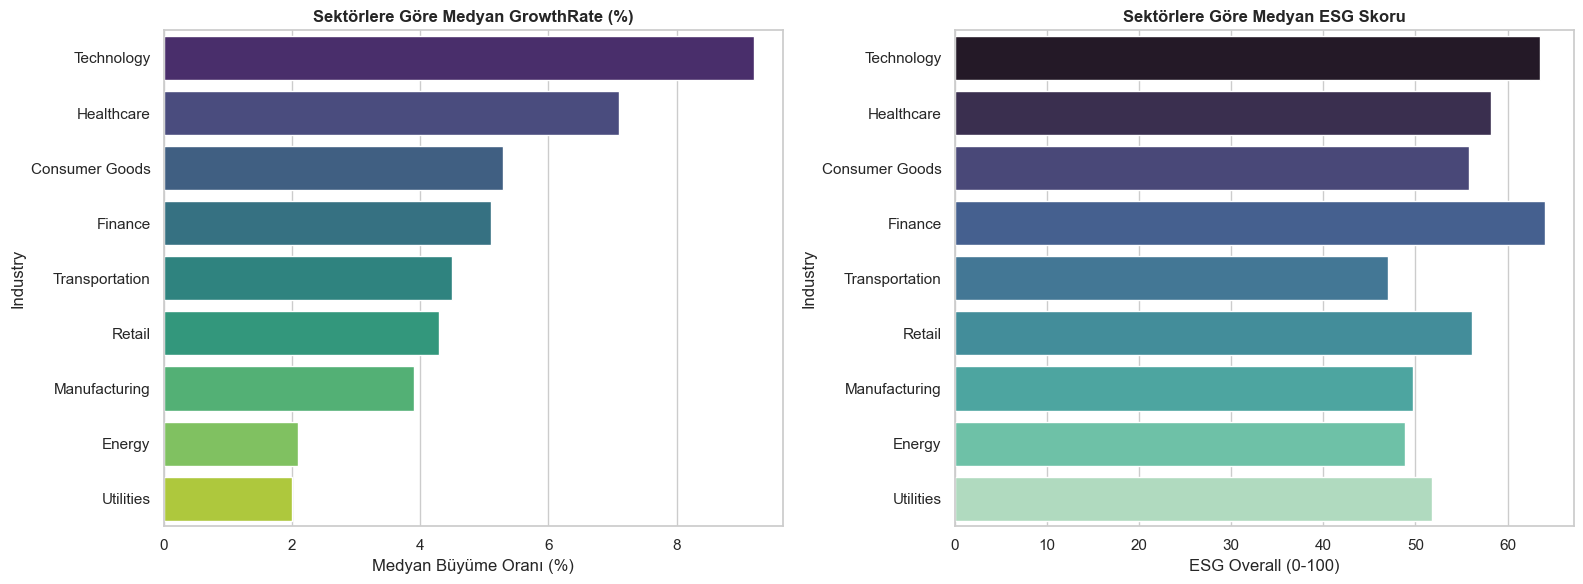


SEKTÖR BAZINDA GROWTHRATE ↔ DİĞER DEĞİŞKENLER KORELASYONU

RETAIL (1166 gözlem)
--------------------------------------------------
Revenue              0.300
CarbonEmissions      0.287
EnergyConsumption    0.287
WaterUsage           0.287
MarketCap            0.223
ESG_Social           0.067
ProfitMargin        -0.011
ESG_Overall         -0.028
ESG_Environmental   -0.046
ESG_Governance      -0.071

TRANSPORTATION (1287 gözlem)
--------------------------------------------------
Revenue              0.293
WaterUsage           0.287
CarbonEmissions      0.287
EnergyConsumption    0.287
ESG_Governance       0.167
MarketCap            0.166
ESG_Overall          0.104
ProfitMargin         0.023
ESG_Environmental    0.021
ESG_Social          -0.006

TECHNOLOGY (1045 gözlem)
--------------------------------------------------
ESG_Governance       0.057
Revenue              0.047
CarbonEmissions      0.045
EnergyConsumption    0.045
WaterUsage           0.045
ESG_Overall          0.045
ESG_Soci

,Revenue,MarketCap,ESG_Environmental,WaterUsage,CarbonEmissions,EnergyConsumption,ESG_Overall,ProfitMargin,ESG_Governance,ESG_Social
Retail,0.300,0.223,-0.046,0.287,0.287,0.287,-0.028,-0.011,-0.071,0.067
Transportation,0.293,0.166,0.021,0.287,0.287,0.287,0.104,0.023,0.167,-0.006
Technology,0.047,0.022,-0.021,0.045,0.045,0.045,0.045,-0.062,0.057,0.034
Finance,0.105,0.018,-0.040,0.098,0.098,0.098,0.039,-0.057,0.018,0.068
Healthcare,0.222,0.155,0.095,0.218,0.218,0.218,0.037,-0.053,-0.025,0.022
Energy,0.329,0.278,-0.099,0.328,0.328,0.328,-0.013,0.032,0.061,-0.005
Consumer Goods,0.135,0.079,0.076,0.129,0.129,0.129,0.056,-0.032,0.043,-0.012
Utilities,0.177,0.123,0.062,0.157,0.157,0.157,-0.026,-0.023,-0.045,-0.054
Manufacturing,0.139,0.110,-0.016,0.150,0.150,0.150,-0.066,-0.020,-0.094,-0.015



→ 'growthrate_correlations_by_sector.csv' kaydedildi.


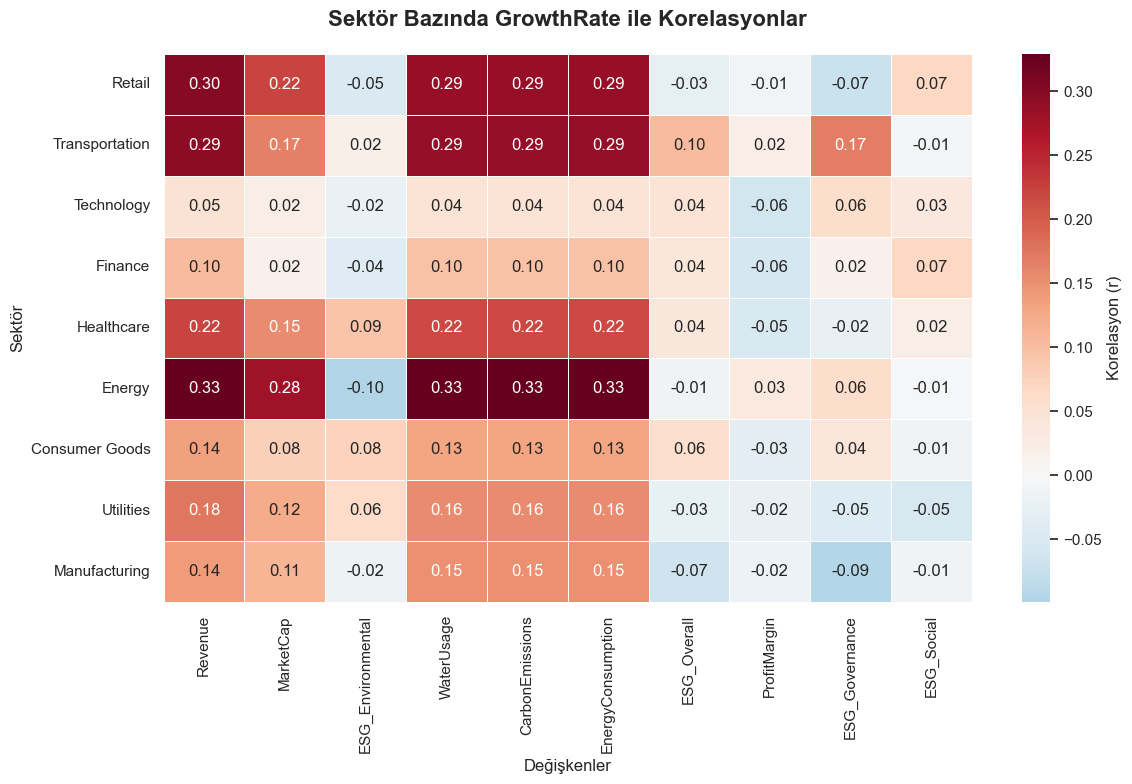


Tüm analizler tamamlandı! Dosyalar ve grafikler kaydedildi.


In [23]:
# ========================================================
#  SEKTÖR BAZLI ANALİZLER 
# ========================================================

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

# -------------------------------------------------------
# 1. SEKTÖR ORTALAMALARI
# -------------------------------------------------------
print("=== SEKTÖR BAZINDA MEDYAN DEĞERLER ===")

agg_cols = [
    'Revenue', 'ProfitMargin', 'MarketCap', 'GrowthRate',
    'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance',
    'CarbonEmissions', 'WaterUsage', 'EnergyConsumption'
]

sector_summary = df.groupby('Industry')[agg_cols].median().round(2)
sector_summary = sector_summary.sort_values('GrowthRate', ascending=False)

print(sector_summary)
sector_summary.to_csv('sector_summary_medians.csv')
print("\n→ 'sector_summary_medians.csv' kaydedildi.")

# Görsel: GrowthRate vs ESG
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=sector_summary.reset_index(), x='GrowthRate', y='Industry', ax=ax1, palette='viridis')
ax1.set_title('Sektörlere Göre Medyan GrowthRate (%)', fontweight='bold')
ax1.set_xlabel('Medyan Büyüme Oranı (%)')

sns.barplot(data=sector_summary.reset_index(), x='ESG_Overall', y='Industry', ax=ax2, palette='mako')
ax2.set_title('Sektörlere Göre Medyan ESG Skoru', fontweight='bold')
ax2.set_xlabel('ESG Overall (0-100)')

plt.tight_layout()
plt.savefig('sector_growth_vs_esg.png', dpi=300, bbox_inches='tight')
plt.show()

# -------------------------------------------------------
# 2. SEKTÖR BAZLI GROWTHRATE KORELASYONLARI 
# -------------------------------------------------------
print("\n" + "="*70)
print("SEKTÖR BAZINDA GROWTHRATE ↔ DİĞER DEĞİŞKENLER KORELASYONU")
print("="*70)

correlation_by_sector = {}

for industry in df['Industry'].unique():
    subset = df[df['Industry'] == industry]
    
    if len(subset) < 20:  # çok küçük sektörleri atla
        continue
        
    corr = subset[agg_cols].corr()['GrowthRate'].drop('GrowthRate', errors='ignore')
    corr_sorted = corr.sort_values(ascending=False)
    correlation_by_sector[industry] = corr_sorted
    
    print(f"\n{industry.upper()} ({len(subset)} gözlem)")
    print("-" * 50)
    print(corr_sorted.round(3).to_string())

# Genel korelasyonları hesapla ve sırala
all_corrs = df[agg_cols].corr()['GrowthRate'].drop('GrowthRate', errors='ignore')
sorted_growth_corrs = all_corrs.sort_values(ascending=False)
# ------------------------------------------

# DataFrame'e çevir
corr_df = pd.DataFrame(correlation_by_sector).T

# Genel korelasyona göre sütunları sırala 
corr_df = corr_df.reindex(columns=sorted_growth_corrs.index)

# NaN → 0 yap
corr_df = corr_df.fillna(0)

print("\n→ Tüm sektör korelasyon tablosu:")
display(corr_df.round(3))

corr_df.to_csv('growthrate_correlations_by_sector.csv')
print("\n→ 'growthrate_correlations_by_sector.csv' kaydedildi.")

# Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_df, annot=True, cmap='RdBu_r', center=0, fmt='.2f',
            cbar_kws={'label': 'Korelasyon (r)'}, linewidths=0.5)

plt.title('Sektör Bazında GrowthRate ile Korelasyonlar', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Değişkenler')
plt.ylabel('Sektör')
plt.tight_layout()
plt.savefig('growthrate_correlations_by_sector_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTüm analizler tamamlandı! Dosyalar ve grafikler kaydedildi.")

Temel Betimsel İstatistikler (Ortalama, Sapma, vb.)

--- Sayısal Değişkenlerin Betimsel İstatistikleri ---


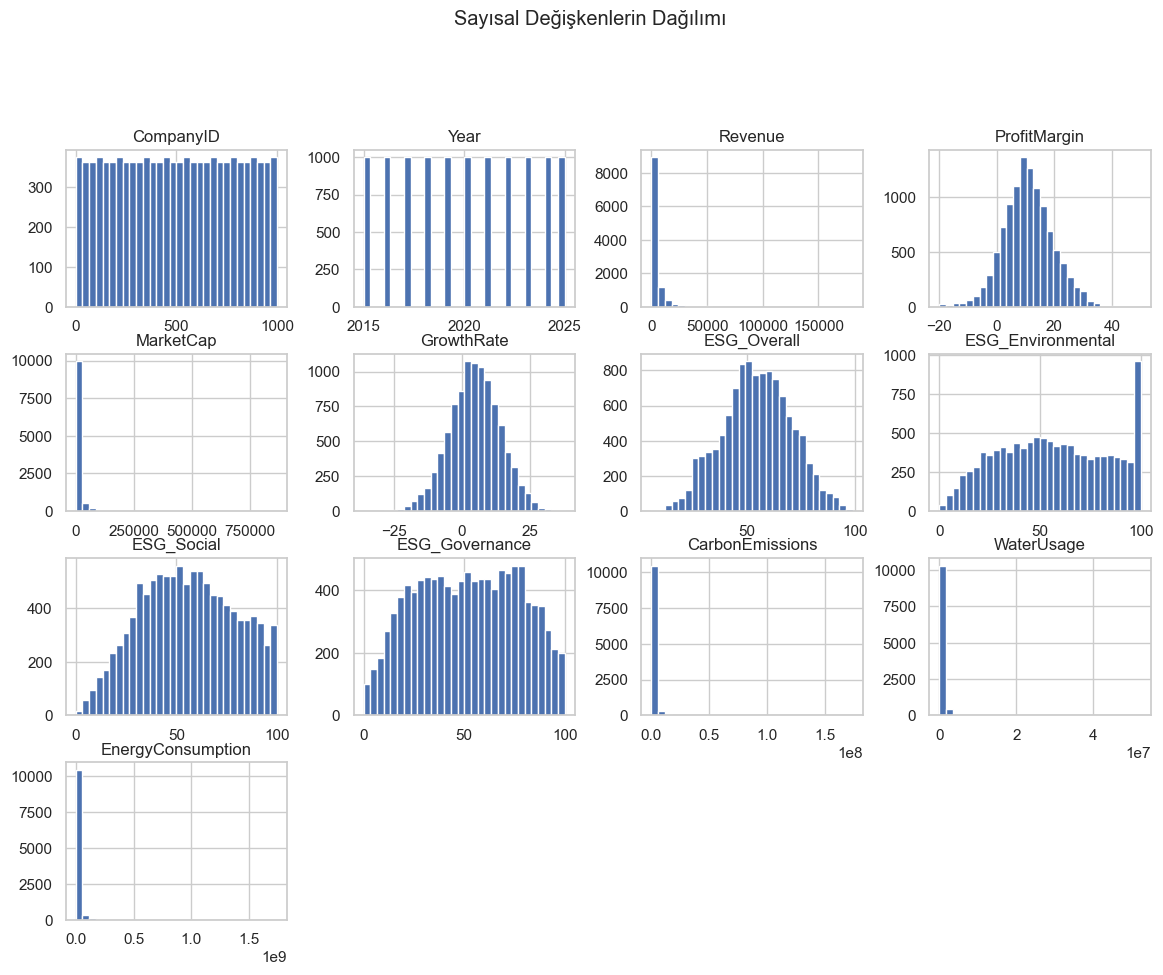

                     count          mean           std     min         50%  \
CompanyID          11000.0  5.005000e+02  2.886881e+02     1.0      500.50   
Year               11000.0  2.020000e+03  3.162421e+00  2015.0     2020.00   
Revenue            11000.0  4.670851e+03  9.969954e+03    35.9     1902.30   
ProfitMargin       11000.0  1.090045e+01  8.758711e+00   -20.0       10.50   
MarketCap          11000.0  1.338062e+04  3.992287e+04     1.8     3096.45   
GrowthRate         10000.0  4.830370e+00  9.424787e+00   -36.0        4.90   
ESG_Overall        11000.0  5.461527e+01  1.589394e+01     6.3       54.60   
ESG_Environmental  11000.0  5.641699e+01  2.676723e+01     0.0       55.60   
ESG_Social         11000.0  5.566058e+01  2.335615e+01     0.0       55.15   
ESG_Governance     11000.0  5.176765e+01  2.532337e+01     0.0       52.10   
CarbonEmissions    11000.0  1.271462e+06  5.067760e+06  2042.2   292073.45   
WaterUsage         11000.0  5.600442e+05  1.565686e+06  1021.1  

In [24]:
print("--- Sayısal Değişkenlerin Betimsel İstatistikleri ---")

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].hist(figsize=(14, 10), bins=30)
plt.suptitle("Sayısal Değişkenlerin Dağılımı", y=1.02)
plt.show()



# .T (transpoze) tabloyu daha okunabilir kılar
desc_stats = df.describe().T
print(desc_stats[['count', 'mean', 'std', 'min', '50%', 'max']])

# Özellikle odaklanacağımız değişkenlerin özetini ayrıca vurgulayalım
print("\n--- Odak Değişkenler İçin Özet (ProfitMargin & ESG_Overall) ---")
print(df[['ProfitMargin', 'ESG_Overall']].describe().T[['count', 'mean', 'std', 'min', 'max']])





Korelasyon Analizi


'GrowthRate' Sütununun Diğer Özellikler ile Korelasyonu:
(İyileştirilmiş veriye göre sıralanmıştır)
--------------------------------------------------
Revenue              0.165195
MarketCap            0.130358
ESG_Environmental    0.102402
WaterUsage           0.100895
CarbonEmissions      0.086584
EnergyConsumption    0.077353
ESG_Overall          0.068218
ProfitMargin         0.060733
ESG_Governance       0.013702
ESG_Social           0.007177
--------------------------------------------------

Korelasyon grafiği 'growthrate_correlations.png' olarak kaydedildi.


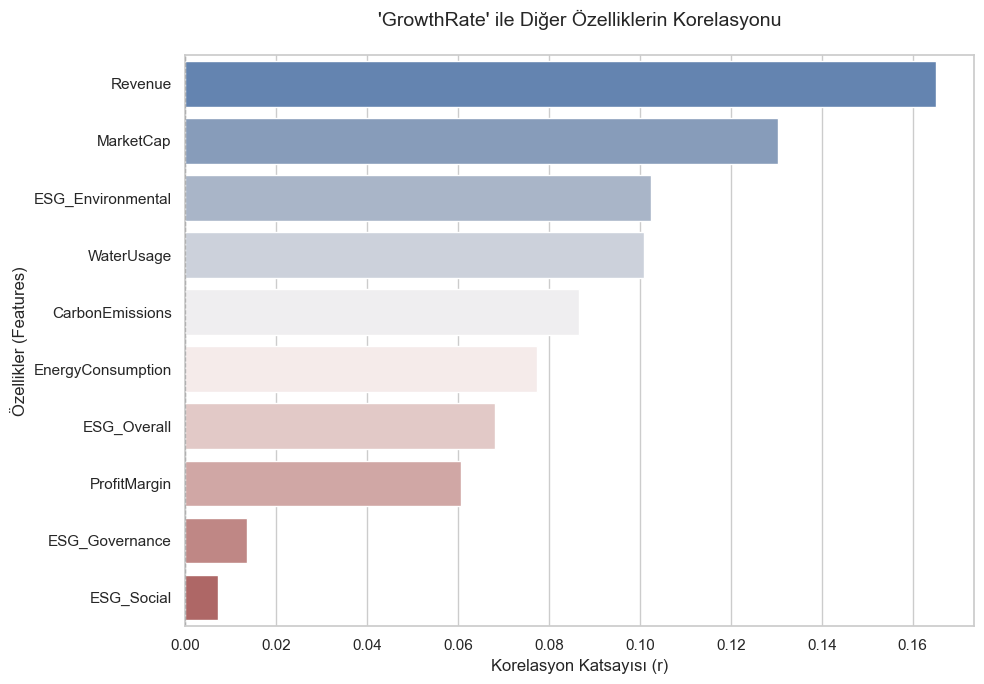

In [25]:

# İlgili tüm nümerik özellikleri seçelim
corr_features = [
    'GrowthRate', 'Revenue', 'ProfitMargin', 'MarketCap', 
    'ESG_Overall', 'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 
    'CarbonEmissions', 'WaterUsage', 'EnergyConsumption'
]

# Veri setinde var olan sütunlarla filtrele
valid_features = [col for col in corr_features if col in df.columns]

# Korelasyon matrisini oluştur
corr_matrix = df[valid_features].corr()

# Sadece 'GrowthRate' sütununu seç, kendini (1.00) listeden çıkar
growth_correlations = corr_matrix['GrowthRate'].drop('GrowthRate')

# Net saptama için korelasyonları en güçlüden en zayıfa sırala
sorted_growth_corrs = growth_correlations.sort_values(ascending=False)

print("\n'GrowthRate' Sütununun Diğer Özellikler ile Korelasyonu:")
print("(İyileştirilmiş veriye göre sıralanmıştır)")
print("-" * 50)
print(sorted_growth_corrs.to_string()) # .to_string() ile daha güzel format
print("-" * 50)


# --- 4. Görselleştirme (Bar Grafiği) ---
plt.figure(figsize=(10, 7))
# 'vlag' paleti pozitifler için kırmızı, negatifler için mavi tonlarını verir
sns.barplot(x=sorted_growth_corrs.values, y=sorted_growth_corrs.index, palette='vlag')
plt.title("'GrowthRate' ile Diğer Özelliklerin Korelasyonu\n", fontsize=14)
plt.xlabel("Korelasyon Katsayısı (r)")
plt.ylabel("Özellikler (Features)")
# 0 noktasını belirginleştirmek için bir çizgi ekle
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('growthrate_correlations.png')

print("\nKorelasyon grafiği 'growthrate_correlations.png' olarak kaydedildi.")

EKSIK DEGERLERI MEDYAN ILE DOLDURMA

In [26]:
# ----------------------------------------------------------------------
# NaN değerlerini doldurma işlemi
# ----------------------------------------------------------------------

# 'CompanyID' sütununa göre gruplama yapılır.
# transform() metodu ile her bir şirketin GrowthRate medyanı hesaplanır.
# fillna() ile NaN değerler bu medyan ile doldurulur.
df['GrowthRate'] = df.groupby('CompanyID')['GrowthRate'].transform(lambda x: x.fillna(x.median()))



--- Eksik Değerler ---


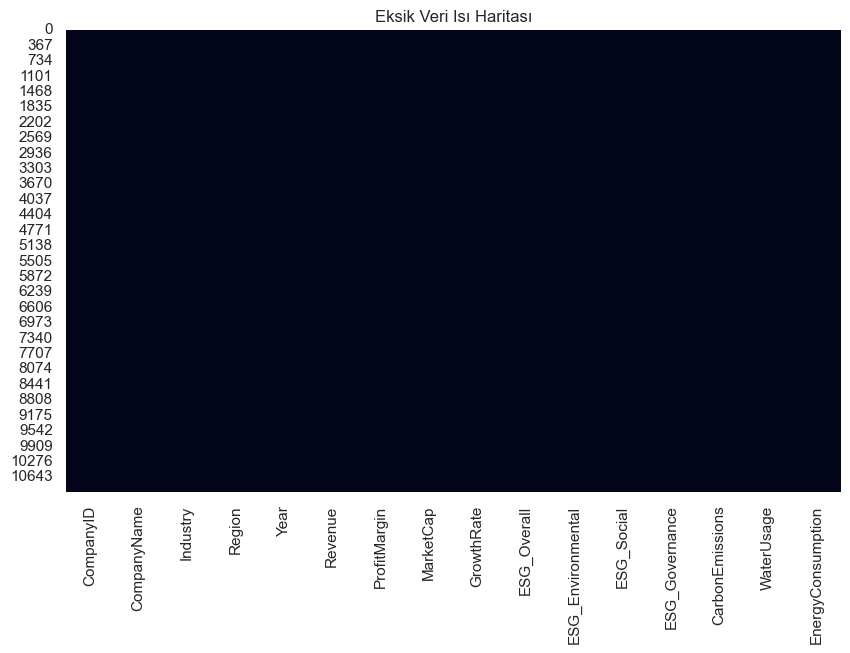

--- Veri Seti Genel Bilgileri ---
Shape: (11000, 16)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CompanyID          11000 non-null  int64  
 1   CompanyName        11000 non-null  object 
 2   Industry           11000 non-null  object 
 3   Region             11000 non-null  object 
 4   Year               11000 non-null  int64  
 5   Revenue            11000 non-null  float64
 6   ProfitMargin       11000 non-null  float64
 7   MarketCap          11000 non-null  float64
 8   GrowthRate         11000 non-null  float64
 9   ESG_Overall        11000 non-null  float64
 10  ESG_Environmental  11000 non-null  float64
 11  ESG_Social         11000 non-null  float64
 12  ESG_Governance     11000 non-null  float64
 13  CarbonEmissions    11000 non-null  float64
 14  WaterUsage         11000 non-null  float64
 15  EnergyCons

,CompanyID,CompanyName,Industry,Region,Year,Revenue,ProfitMargin,MarketCap,GrowthRate,ESG_Overall,ESG_Environmental,ESG_Social,ESG_Governance,CarbonEmissions,WaterUsage,EnergyConsumption
count,11000.000000,11000,11000,11000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,1.100000e+04,1.100000e+04,1.100000e+04
unique,NaN,1000,9,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Company_1000,Healthcare,Asia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,11,1331,1672,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,500.500000,NaN,NaN,NaN,2020.000000,4670.850591,10.900455,13380.622236,4.831100,54.615273,56.416991,55.660582,51.767655,1.271462e+06,5.600442e+05,1.165839e+07
std,288.688113,NaN,NaN,NaN,3.162421,9969.954369,8.758711,39922.870373,9.189006,15.893937,26.767233,23.356152,25.323370,5.067760e+06,1.565686e+06,5.095836e+07
min,1.000000,NaN,NaN,NaN,2015.000000,35.900000,-20.000000,1.800000,-36.000000,6.300000,0.000000,0.000000,0.000000,2.042200e+03,1.021100e+03,5.105500e+03
25%,250.750000,NaN,NaN,NaN,2017.000000,938.775000,5.300000,1098.525000,-1.100000,44.100000,34.700000,37.600000,30.775000,1.228530e+05,6.488467e+04,3.069161e+05
50%,500.500000,NaN,NaN,NaN,2020.000000,1902.300000,10.500000,3096.450000,4.900000,54.600000,55.600000,55.150000,52.100000,2.920734e+05,2.038805e+05,1.221745e+06
75%,750.250000,NaN,NaN,NaN,2023.000000,4342.625000,16.300000,9995.500000,10.800000,65.600000,79.000000,73.800000,73.000000,7.407311e+05,5.251880e+05,5.616437e+06


In [9]:
print("\n--- Eksik Değerler ---")
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "MissingCount": missing,
    "MissingPercent": missing_pct
})

missing_df

# Eksik değerlerin sayısı ve yüzdesi
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Eksik Veri Isı Haritası")
plt.show()

print("--- Veri Seti Genel Bilgileri ---")
print("Shape:", df.shape)
print("\nInfo:")
df.info()

print("\nDescribe:")
df.describe(include="all")


 --- 1. İstatistiksel Analiz ---
 Sektör (Industry) ve Bölgeye (Region) göre gruplayarak Revenue ve ESG_Overall için
 ortalama, standart sapma, min, max ve kartilleri (%25, %50-Medyan, %75) hesapla.

İstatistiksel Özet (İlk 5 Satır):
                             Revenue                                   \
                               count         mean          std    min   
Industry       Region                                                   
Consumer Goods Africa          165.0  1494.768485  1009.029611  197.0   
               Asia            209.0  1620.619139   990.700250  238.0   
               Europe          132.0  2864.746212  3674.545223  337.0   
               Latin America   176.0  2059.805682  1399.645596  471.9   
               Middle East     121.0  2414.095868  1584.991827  534.5   

                                                                    \
                                   25%      50%       75%      max   
Industry       Region                                                
Consumer Goods Africa          740.800  1282.80  1920.900   4502.4   
               Asia            874.400  1402.80  2089.000   5837.6   
               Europe          

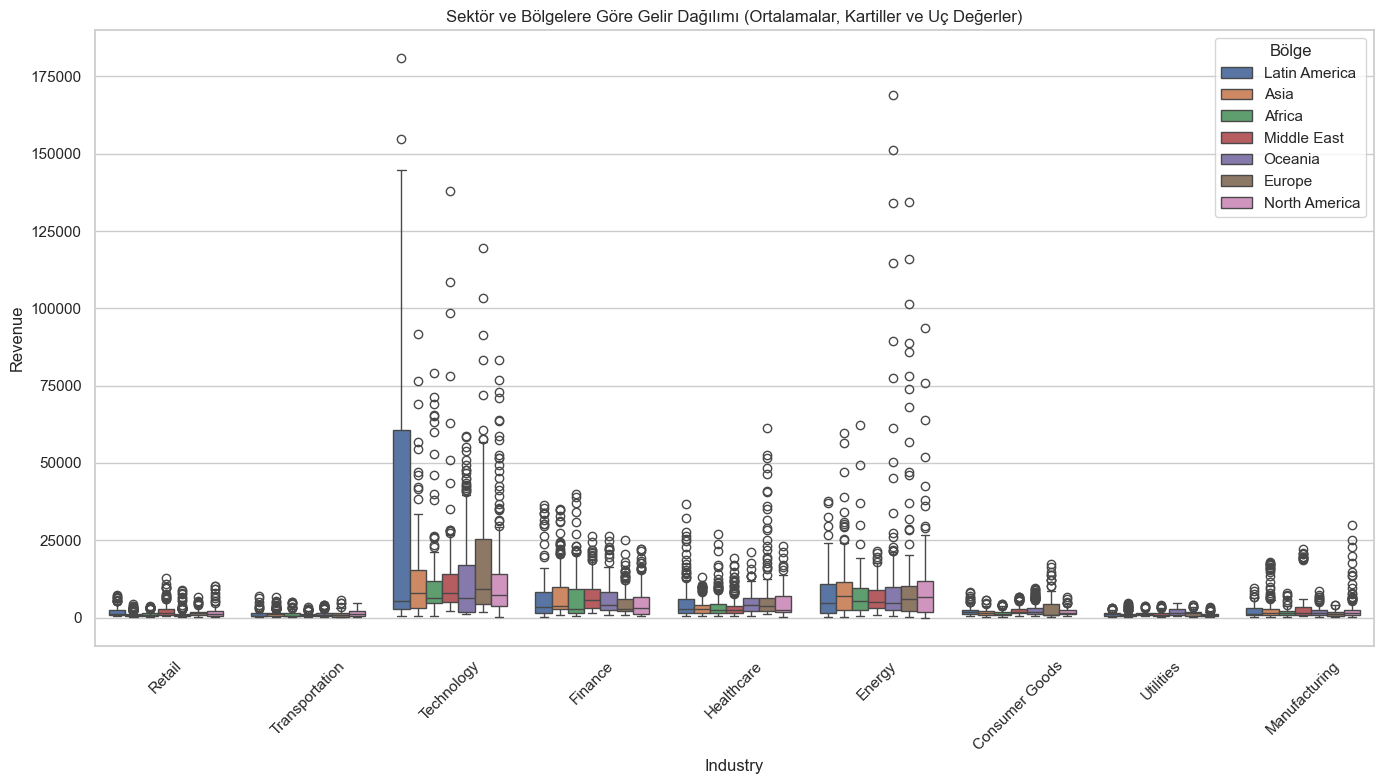

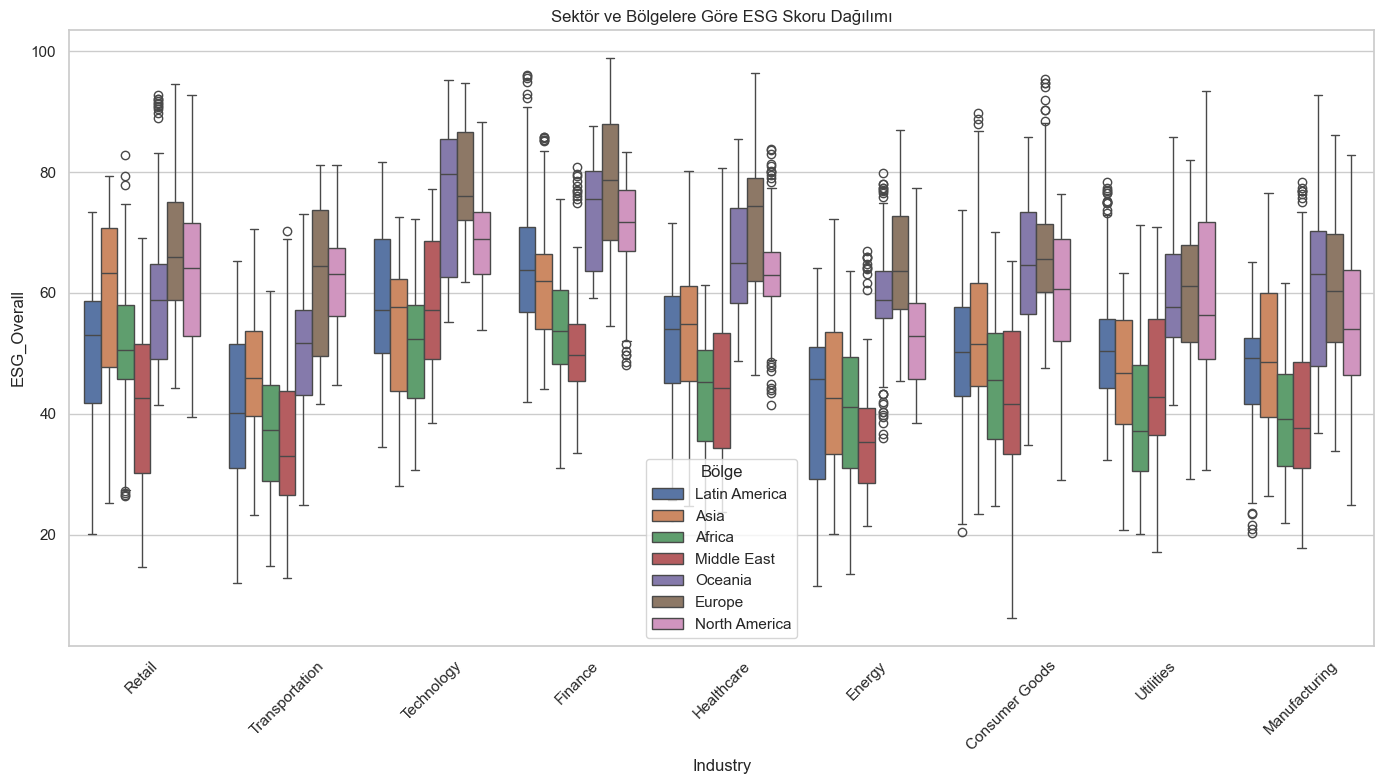

In [27]:


# --- 1. İstatistiksel Analiz ---
# Sektör (Industry) ve Bölgeye (Region) göre gruplayarak Revenue ve ESG_Overall için
# ortalama, standart sapma, min, max ve kartilleri (%25, %50-Medyan, %75) hesapla.
# Bu tablo sayısal karşılaştırma için kullanılır.
grup_istatistikleri = df.groupby(['Industry', 'Region'])[['Revenue', 'ESG_Overall']].describe()

print("İstatistiksel Özet (İlk 5 Satır):")
print(grup_istatistikleri.head())

# İsterseniz bu istatistikleri bir dosyaya kaydedebilirsiniz:
# grup_istatistikleri.to_csv('sektor_bolge_istatistikleri.csv')

# --- 2. Görselleştirme (Boxplots) ---
# Boxplot (Kutu Grafiği); medyanı, kartilleri ve uç değerleri (outliers) 
# aynı anda göstermek için en iyi yöntemdir.

sns.set(style="whitegrid")

# Grafik 1: Sektör ve Bölgelere Göre Gelir (Revenue) Dağılımı
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='Industry', y='Revenue', hue='Region')
plt.title('Sektör ve Bölgelere Göre Gelir Dağılımı (Ortalamalar, Kartiller ve Uç Değerler)')
plt.xticks(rotation=45)
plt.legend(title='Bölge')
plt.tight_layout()
plt.savefig('revenue_dagilimi.png') # Grafiği kaydet
plt.show()

# Grafik 2: Sektör ve Bölgelere Göre ESG Skoru Dağılımı
plt.figure(figsize=(14, 8))
sns.boxplot(data=df, x='Industry', y='ESG_Overall', hue='Region')
plt.title('Sektör ve Bölgelere Göre ESG Skoru Dağılımı')
plt.xticks(rotation=45)
plt.legend(title='Bölge')
plt.tight_layout()
plt.savefig('esg_dagilimi.png') # Grafiği kaydet
plt.show()

Korelasyon (Doldurulmuş veriyle)

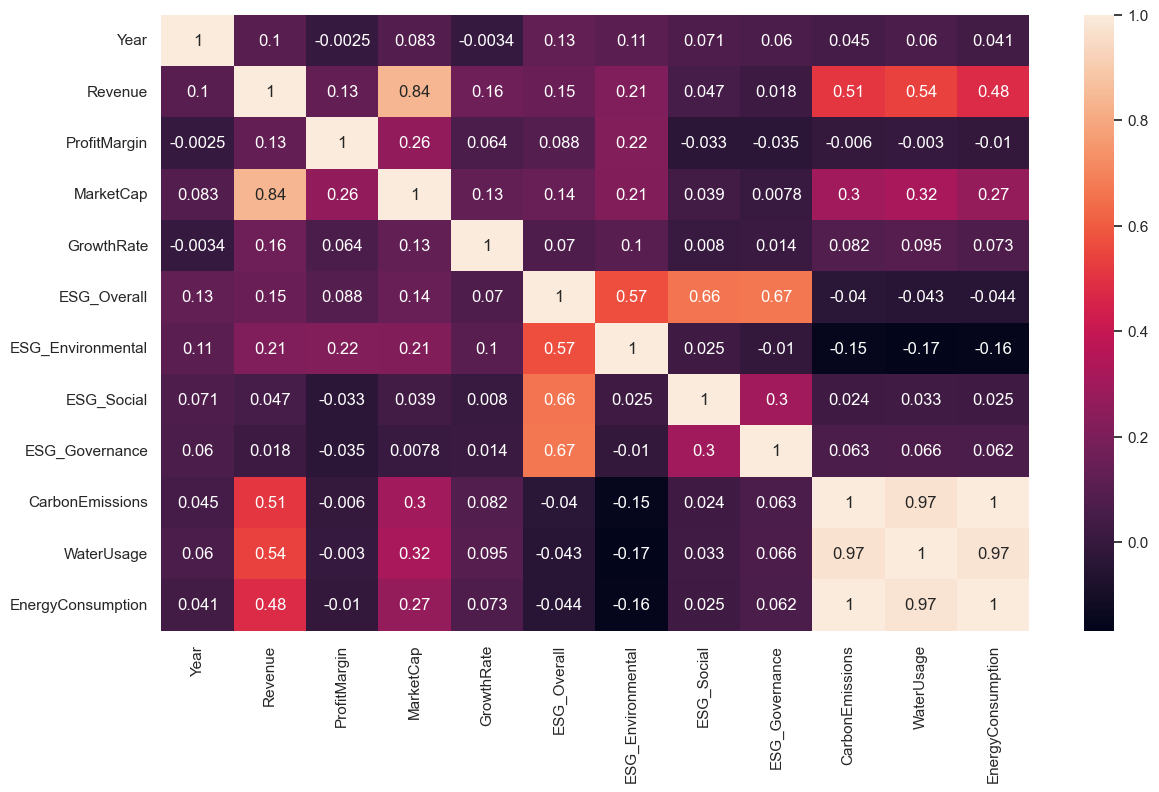

In [28]:
col=['Year', 'Revenue','ProfitMargin', 'MarketCap', 'GrowthRate', 'ESG_Overall',
     'ESG_Environmental', 'ESG_Social', 'ESG_Governance', 'CarbonEmissions',
     'WaterUsage', 'EnergyConsumption']
df[col].corr().T


sns.heatmap(df[col].corr(),annot=True)
plt.show()